# Nuclear Waste Canister Temperature Prediction — Neural Network
**CIVIL-226 - Introduction to Machine Learning for Engineers — EPFL**  
**Team name:** [To fill]  
**Members:** [To fill]

## Objective
Predict the temperature around nuclear waste canisters at unobserved sensor positions,
using heating power, time, spatial coordinates, and cumulative energy.

This notebook implements a deep neural network trained with AdamW optimizer and Huber loss,
with a sensor-based train/validation split to better estimate generalization performance.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import torch
import torchvision
import pandas as pd
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
sensors = pd.read_parquet("data/sensors.parquet")
train = pd.read_parquet("data/train.parquet")
test = pd.read_parquet("data/test.parquet")

## Merge sensor positions into train data

In [3]:
train_full = train.merge(sensors, on="sensor", how="left")
print(train_full.head())
print(train_full.shape)

  sensor       time      power  temperature     coor_x  coor_y  coor_z
0   N102        0.0  1487.9647    17.514430  46.131474     3.5     0.0
1   N102   864000.0  1487.2888    17.820795  46.131474     3.5     0.0
2   N102  1728000.0  1486.6129    17.573187  46.131474     3.5     0.0
3   N102  2592000.0  1485.9369    16.513235  46.131474     3.5     0.0
4   N102  3456000.0  1485.2610    16.303427  46.131474     3.5     0.0
(6626928, 7)


## Clean missing values

In [4]:
train_full = train_full.dropna()
print(train_full.shape)
print(train_full.columns)

(6527525, 7)
Index(['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y', 'coor_z'], dtype='str')


## Data exploration

Temperature min: -292.15085
Temperature max: 6039.05

Power min: 0.0
Power max: 1500.0

Time min: 0.0
Time max: 7884000000.0


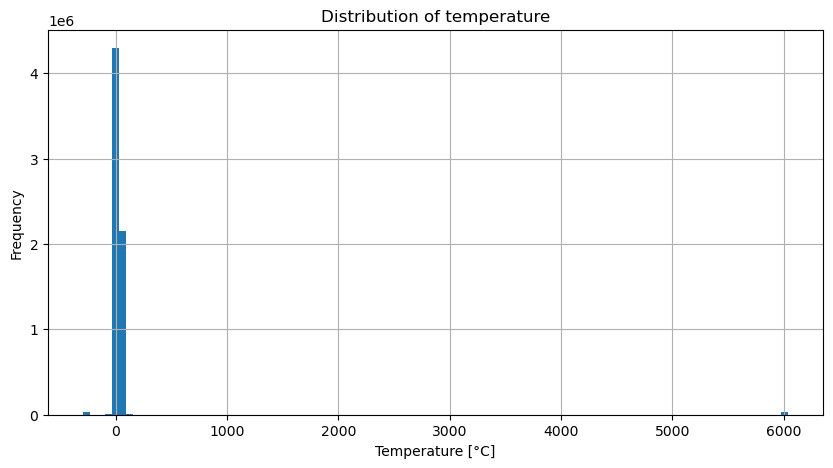

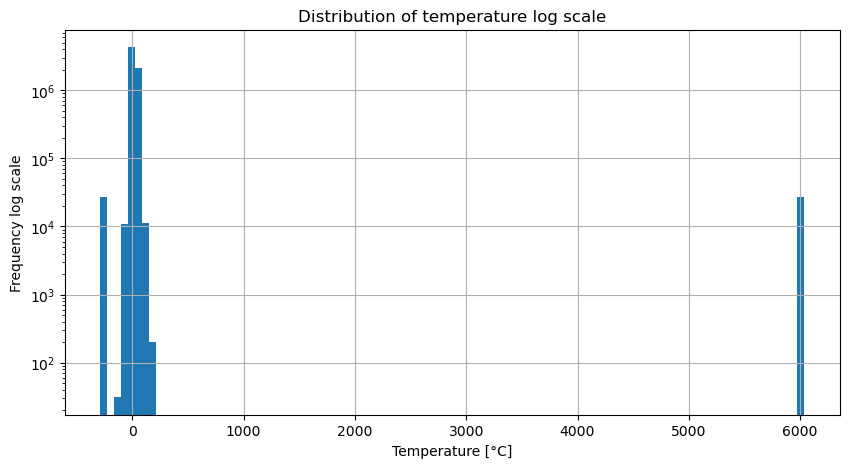

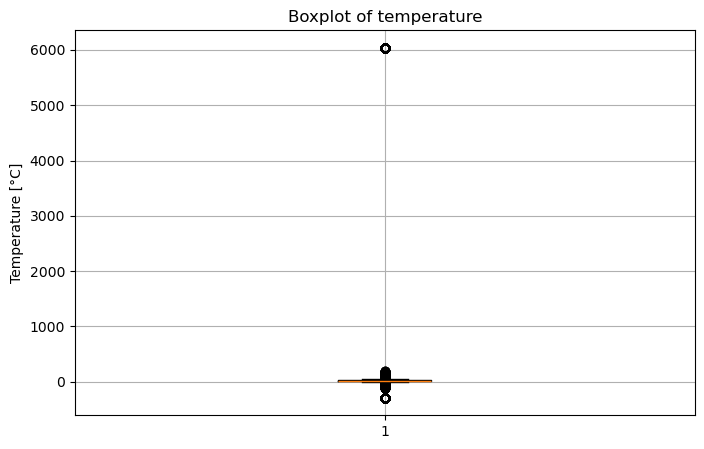

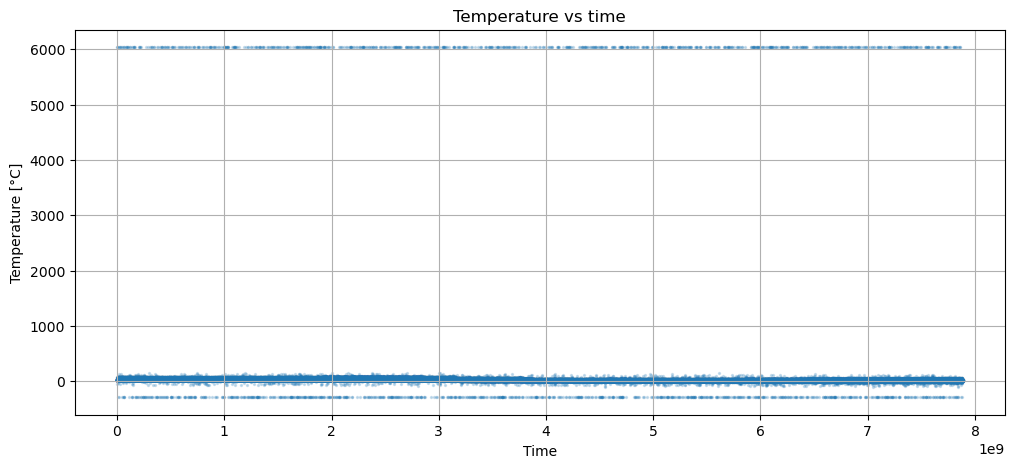

In [5]:
train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
])
print("Temperature min:", train_full["temperature"].min())
print("Temperature max:", train_full["temperature"].max())

print("\nPower min:", train_full["power"].min())
print("Power max:", train_full["power"].max())

print("\nTime min:", train_full["time"].min())
print("Time max:", train_full["time"].max())
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency")
plt.title("Distribution of temperature")
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.yscale("log")
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency log scale")
plt.title("Distribution of temperature log scale")
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 5))
plt.boxplot(train_full["temperature"], vert=True, showfliers=True)
plt.ylabel("Temperature [°C]")
plt.title("Boxplot of temperature")
plt.grid(True)
plt.show()
sample_df = train_full.sample(n=200_000, random_state=42)

plt.figure(figsize=(12, 5))
plt.scatter(
    sample_df["time"],
    sample_df["temperature"],
    s=2,
    alpha=0.2
)
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.title("Temperature vs time")
plt.grid(True)
plt.show()

## Remove outliers

In [6]:
train_full = train_full[(train_full['temperature']>=0) & (train_full['temperature']<1000)]
print(train_full.shape)


(6337625, 7)


## Data exploration ripuliti

Temperature min: 1.7899116e-06
Temperature max: 186.7141

Power min: 0.0
Power max: 1500.0

Time min: 0.0
Time max: 7884000000.0


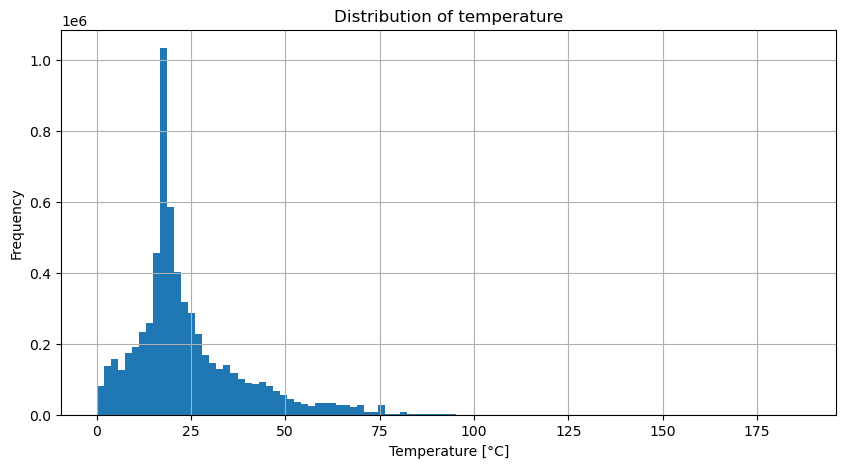

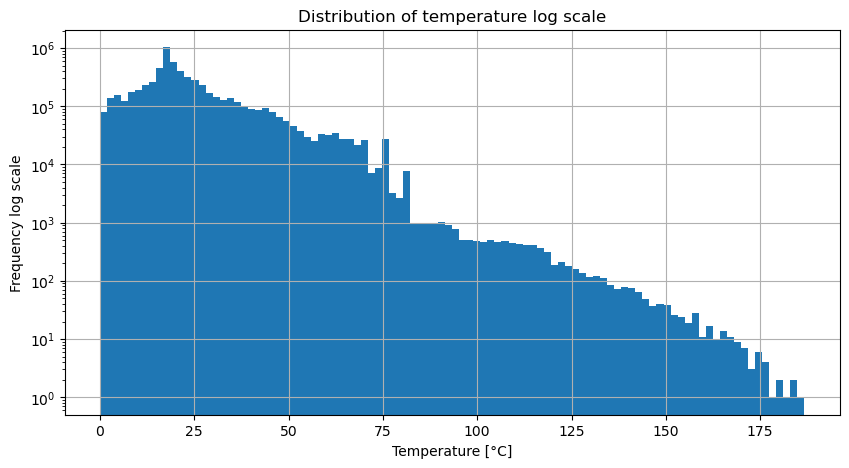

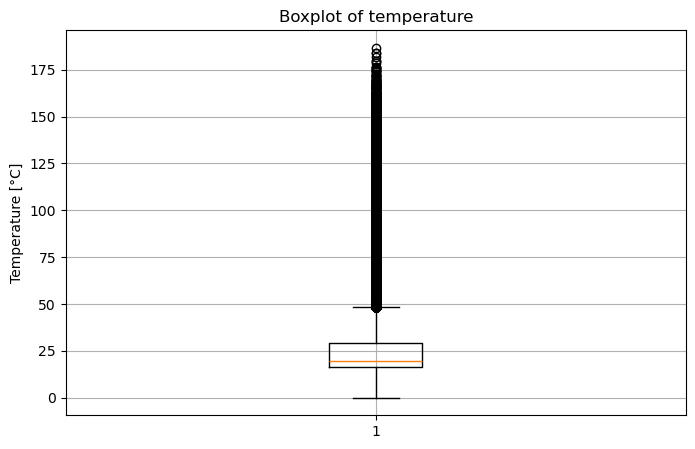

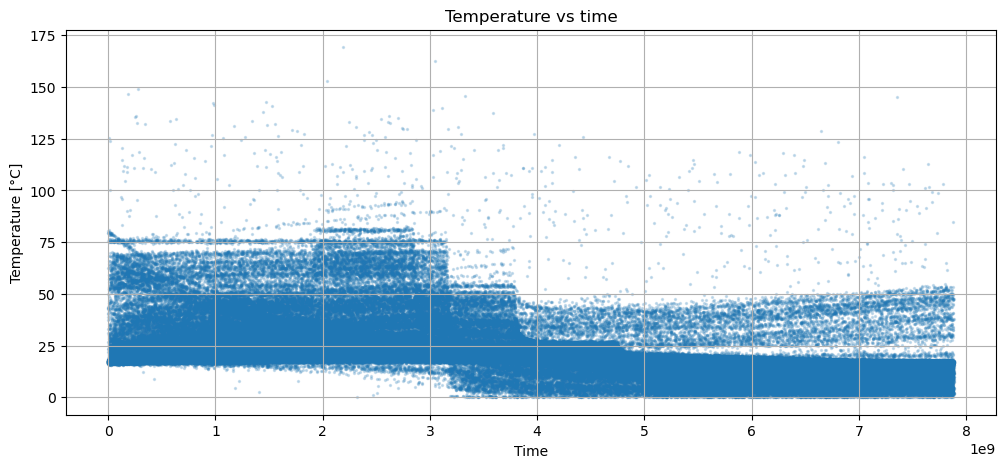

In [7]:
train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
])
print("Temperature min:", train_full["temperature"].min())
print("Temperature max:", train_full["temperature"].max())

print("\nPower min:", train_full["power"].min())
print("Power max:", train_full["power"].max())

print("\nTime min:", train_full["time"].min())
print("Time max:", train_full["time"].max())
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency")
plt.title("Distribution of temperature")
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.yscale("log")
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency log scale")
plt.title("Distribution of temperature log scale")
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 5))
plt.boxplot(train_full["temperature"], vert=True, showfliers=True)
plt.ylabel("Temperature [°C]")
plt.title("Boxplot of temperature")
plt.grid(True)
plt.show()
sample_df = train_full.sample(n=200_000, random_state=42)

plt.figure(figsize=(12, 5))
plt.scatter(
    sample_df["time"],
    sample_df["temperature"],
    s=2,
    alpha=0.2
)
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.title("Temperature vs time")
plt.grid(True)
plt.show()

## Note: this cell can be skipped

In [8]:
train_buffer = train_full[train_full["coor_x"] < 1.4].copy()
train_opa = train_full[train_full["coor_x"] > 1.4].copy()
print(train_buffer.shape)
print(train_opa.shape)



(1157405, 7)
(4923004, 7)


## Cumulative energy feature

In [9]:
# Creo una tabella temporale unica con time e power
power_time = (
    train_full[["time", "power"]]
    .drop_duplicates()
    .sort_values("time")
    .copy()
)

# Differenza temporale tra istanti successivi
power_time["dt"] = power_time["time"].diff().fillna(0)

# Energia cumulata approssimata
power_time["cum_energy"] = (power_time["power"] * power_time["dt"]).cumsum()

# Merge nel dataset principale
train_full = train_full.merge(
    power_time[["time", "cum_energy"]],
    on="time",
    how="left"
)

In [10]:
train_full["time"] = train_full["time"] / 1e7
train_full = train_full.dropna(subset=["temperature"])


## Train/validation split by sensor & normalization

In [11]:
from sklearn.preprocessing import StandardScaler
import numpy as np

feature_cols = [
    "coor_x",
    "coor_y",
    "power",
    "time",
    "cum_energy"
]
target_col = "temperature"

# Lista dei sensori disponibili
unique_sensors = train_full["sensor"].unique()

# Split dei sensori, non delle singole righe
rng = np.random.default_rng(42)

val_sensors = rng.choice(
    unique_sensors,
    size=int(0.2 * len(unique_sensors)),
    replace=False
)

train_sensors = np.setdiff1d(unique_sensors, val_sensors)

# Creo train e validation dataframe
train_df = train_full[train_full["sensor"].isin(train_sensors)].copy()
val_df = train_full[train_full["sensor"].isin(val_sensors)].copy()

# Controllo: nessun sensore deve essere in entrambi
assert set(train_df["sensor"]).isdisjoint(set(val_df["sensor"]))

print(f"Numero sensori train: {train_df['sensor'].nunique()}")
print(f"Numero sensori validation: {val_df['sensor'].nunique()}")
print(f"Righe train: {len(train_df)}")
print(f"Righe validation: {len(val_df)}")

# Estraggo X e y dopo lo split per sensore
X_train = train_df[feature_cols].values
y_train = train_df[[target_col]].values

X_val = val_df[feature_cols].values
y_val = val_df[[target_col]].values

# Normalizzazione
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit solo sul training set
X_train_norm = scaler_X.fit_transform(X_train)
X_val_norm = scaler_X.transform(X_val)

y_train_norm = scaler_y.fit_transform(y_train)
y_val_norm = scaler_y.transform(y_val)
#Check: devo stampare tutti 0
print(np.isnan(X_train_norm).sum(), np.isinf(X_train_norm).sum())
print(np.isnan(y_train_norm).sum(), np.isinf(y_train_norm).sum())
print(np.isnan(X_val_norm).sum(), np.isinf(X_val_norm).sum())
print(np.isnan(y_val_norm).sum(), np.isinf(y_val_norm).sum())

Numero sensori train: 192
Numero sensori validation: 48
Righe train: 13244596
Righe validation: 3312731
0 0
0 0
0 0
0 0


In [12]:
print(train_full["temperature"].isna().sum())
print(train_full.isna().sum())


0
sensor         0
time           0
power          0
temperature    0
coor_x         0
coor_y         0
coor_z         0
cum_energy     0
dtype: int64


In [13]:
print(train_full[train_full["temperature"].isna()].head())


Empty DataFrame
Columns: [sensor, time, power, temperature, coor_x, coor_y, coor_z, cum_energy]
Index: []


## Neural Network architecture

In [14]:
class TemperatureNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)   # output lineare: temperatura normalizzata
        )

    def forward(self, x):
        return self.network(x)

## Weight initialization (Kaiming)

In [15]:
def initialize_weights(model):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")

            if layer.bias is not None:
                nn.init.zeros_(layer.bias)

## Create tensors and move to GPU

In [16]:
X_train_tensor = torch.tensor(X_train_norm, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train_norm, dtype=torch.float32, device=device)
X_val_tensor   = torch.tensor(X_val_norm, dtype=torch.float32, device=device)
y_val_tensor   = torch.tensor(y_val_norm, dtype=torch.float32, device=device)

## Model instantiation

In [17]:
input_dim = X_train_tensor.shape[1]

model = TemperatureNN(input_dim).to(device)

initialize_weights(model)

print(model)

TemperatureNN(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


## Loss, optimizer & regularization

In [26]:
# loss_fn = nn.MSELoss()
# alternativa più robusta agli outlier:
loss_fn = nn.HuberLoss(delta=1.0)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

## Training loop

In [27]:
batch_size = 65536
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    perm = torch.randperm(X_train_tensor.shape[0], device=device)

    train_loss_sum = 0.0

    for i in range(0, X_train_tensor.shape[0], batch_size):
        idx = perm[i:i+batch_size]
        Xb = X_train_tensor[idx]
        yb = y_train_tensor[idx]

        optimizer.zero_grad(set_to_none=True)
        pred = model(Xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * Xb.shape[0]

    train_loss = train_loss_sum / X_train_tensor.shape[0]

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_tensor)
        val_loss = loss_fn(val_pred, y_val_tensor).item()

    print(f"Epoch {epoch:03d} | train {train_loss:.6f} | val {val_loss:.6f}")

Epoch 000 | train 0.033629 | val 0.078277
Epoch 001 | train 0.026594 | val 0.079214
Epoch 002 | train 0.025777 | val 0.079242
Epoch 003 | train 0.025920 | val 0.079354
Epoch 004 | train 0.025907 | val 0.079376
Epoch 005 | train 0.025887 | val 0.079744
Epoch 006 | train 0.025921 | val 0.080103
Epoch 007 | train 0.025823 | val 0.082244
Epoch 008 | train 0.025786 | val 0.080327
Epoch 009 | train 0.025676 | val 0.080250
Epoch 010 | train 0.025658 | val 0.081374
Epoch 011 | train 0.025494 | val 0.081571
Epoch 012 | train 0.025549 | val 0.083119
Epoch 013 | train 0.025439 | val 0.080612
Epoch 014 | train 0.025437 | val 0.082055
Epoch 015 | train 0.025338 | val 0.081742
Epoch 016 | train 0.025437 | val 0.081348
Epoch 017 | train 0.025195 | val 0.080900
Epoch 018 | train 0.025296 | val 0.083073
Epoch 019 | train 0.025094 | val 0.083077
Epoch 020 | train 0.025142 | val 0.080939
Epoch 021 | train 0.025100 | val 0.080485
Epoch 022 | train 0.025075 | val 0.081969
Epoch 023 | train 0.025080 | val 0

## Evaluate on validation set

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model.eval()

with torch.no_grad():
    y_val_pred_norm = model(X_val_tensor).cpu().numpy()

y_val_true_norm = y_val_tensor.cpu().numpy()

# Torno alla scala originale in °C
y_val_pred = scaler_y.inverse_transform(y_val_pred_norm)
y_val_true = scaler_y.inverse_transform(y_val_true_norm)

mae = mean_absolute_error(y_val_true, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
r2 = r2_score(y_val_true, y_val_pred)

print(f"Validation MAE:  {mae:.4f} °C")
print(f"Validation RMSE: {rmse:.4f} °C")
print(f"Validation R2:   {r2:.4f}")

Validation MAE:  3.9043 °C
Validation RMSE: 7.3957 °C
Validation R2:   0.7675


## Compare with baseline

In [29]:
baseline_pred = np.full_like(y_val, y_train.mean())

baseline_mae = mean_absolute_error(y_val, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_pred))

print(f"Baseline MAE:  {baseline_mae:.4f} °C")
print(f"Baseline RMSE: {baseline_rmse:.4f} °C")

Baseline MAE:  11.2912 °C
Baseline RMSE: 15.3451 °C


## Error analysis by sensor

In [30]:
val_results = val_df.copy()
val_results["y_true"] = y_val_true.ravel()
val_results["y_pred"] = y_val_pred.ravel()
val_results["abs_error"] = np.abs(val_results["y_true"] - val_results["y_pred"])
val_results["sq_error"] = (val_results["y_true"] - val_results["y_pred"]) ** 2

sensor_metrics = (
    val_results
    .groupby("sensor")
    .agg(
        mae=("abs_error", "mean"),
        rmse=("sq_error", lambda x: np.sqrt(np.mean(x))),
        coor_x=("coor_x", "first"),
        coor_y=("coor_y", "first"),
        true_mean=("y_true", "mean"),
        pred_mean=("y_pred", "mean")
    )
    .sort_values("mae", ascending=False)
)

print(sensor_metrics.head(20))

              mae       rmse     coor_x    coor_y  true_mean  pred_mean
sensor                                                                 
N749    16.290073  19.508686  15.646701  0.356862  38.071560  21.844742
N245    12.605829  18.085520  11.024173  1.068612  22.592724  34.237217
N201    10.561084  14.894874   0.500000  1.800000  39.289154  49.286564
N269     8.487337  10.628455  11.873100  0.864290  22.000544  30.477610
N862     8.199579  10.405452   6.525898  1.996336  21.471807  28.906996
N236     7.313361  10.774814  26.063416  1.689136  19.574482  26.365135
N732     7.281570   9.636536   2.560348  0.254275  27.498135  33.582455
N413     6.740664   8.793503   4.860546  1.365552  25.240881  30.874170
N853     6.234942   9.116906  11.182720  1.733389  22.497066  16.867754
N234     5.822293  11.979775   7.534472  1.094408  23.810154  22.254080
N674     5.703788   7.054752  49.230310  1.761023  17.055086  11.397504
N813     5.514678   7.957598   5.379134  1.569825  24.965986  29

## Plot predictions vs true values

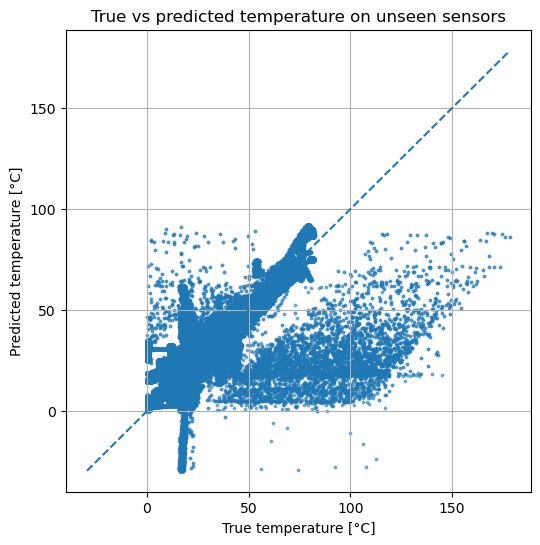

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_val_true, y_val_pred, s=3, alpha=0.3)

min_val = min(y_val_true.min(), y_val_pred.min())
max_val = max(y_val_true.max(), y_val_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("True temperature [°C]")
plt.ylabel("Predicted temperature [°C]")
plt.title("True vs predicted temperature on unseen sensors")
plt.grid(True)
plt.show()

## Error analysis over time

In [32]:
val_results["time_years"] = val_results["time"] * 1e7 / (365.25 * 24 * 3600)

time_error = (
    val_results
    .groupby(pd.qcut(val_results["time_years"], 20, duplicates="drop"))
    .agg(mae=("abs_error", "mean"))
)

print(time_error)

                         mae
time_years                  
(-0.001, 10.678]    1.652277
(10.678, 21.383]    1.476090
(21.383, 32.063]    1.765496
(32.063, 42.768]    2.025566
(42.768, 53.448]    2.146652
(53.448, 64.153]    2.571392
(64.153, 74.831]    2.615151
(74.831, 85.511]    2.714052
(85.511, 96.189]    3.319473
(96.189, 106.924]   4.006288
(106.924, 117.739]  4.096188
(117.739, 128.528]  4.733551
(128.528, 139.398]  5.069612
(139.398, 150.242]  5.525409
(150.242, 166.368]  5.908733
(166.368, 182.99]   5.150420
(182.99, 199.663]   5.306994
(199.663, 216.367]  5.626857
(216.367, 233.098]  6.012162
(233.098, 249.829]  6.371698


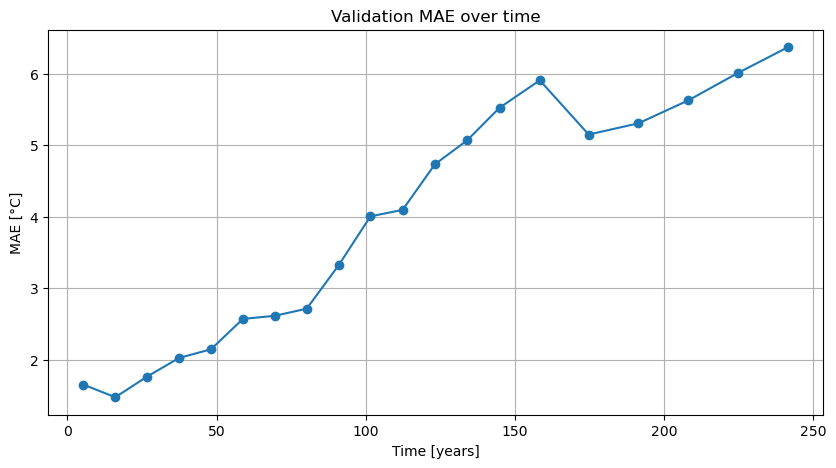

In [33]:
time_error = time_error.reset_index()
time_error["time_mid"] = time_error["time_years"].apply(lambda x: x.mid)

plt.figure(figsize=(10, 5))
plt.plot(time_error["time_mid"], time_error["mae"], marker="o")
plt.xlabel("Time [years]")
plt.ylabel("MAE [°C]")
plt.title("Validation MAE over time")
plt.grid(True)
plt.show()

## Final predictions & submission file

In [ ]:
# ============================================================
# Final predictions & submission
# ============================================================
import numpy as np
import pandas as pd

test = pd.read_parquet('data/test.parquet')
sensors = pd.read_parquet('data/sensors.parquet')

# Merge sensor positions
test_full = test.merge(sensors, on='sensor', how='left')

# Add cumulative energy (same as train)
power_time = (
    test_full[['time', 'power']]
    .drop_duplicates()
    .sort_values('time')
    .copy()
)
power_time['dt']         = power_time['time'].diff().fillna(0)
power_time['cum_energy'] = (power_time['power'] * power_time['dt']).cumsum()
test_full = test_full.merge(power_time[['time', 'cum_energy']], on='time', how='left')

# Normalize time (same as train)
test_full['time'] = test_full['time'] / 1e7

# Prepare features
X_test = test_full[feature_cols].values
X_test_norm = scaler_X.transform(X_test)
X_test_tensor = torch.tensor(X_test_norm, dtype=torch.float32, device=device)

# Predict
model.eval()
with torch.no_grad():
    y_test_pred_norm = model(X_test_tensor).cpu().numpy()

y_test_pred = scaler_y.inverse_transform(y_test_pred_norm).ravel()

# Create submission
submission = pd.DataFrame({
    'Id': np.arange(len(test), dtype=int),
    'temperature': y_test_pred.astype(float)
})

assert list(submission.columns) == ['Id', 'temperature']
assert len(submission) == len(test)
assert np.isfinite(submission['temperature']).all()
assert submission.isna().sum().sum() == 0

submission.to_csv('submission.csv', index=False)
print(f'submission.csv saved — {len(submission)} rows')
print(f'Min: {y_test_pred.min():.2f}°C | Max: {y_test_pred.max():.2f}°C | Mean: {y_test_pred.mean():.2f}°C')
display(submission.head())